# Week 6 — Gymnasium: Famous Examples Only

**From Conway to LangGraph: Agent Systems for Physicists in the LLM Era**  
Università di Bologna · Dipartimento di Fisica

---

## Learning Objectives

By the end of this notebook you will:
1. Install and navigate the **Gymnasium API** — the standard RL environment interface
2. Understand **CartPole-v1** (continuous state, dense reward) and **FrozenLake-v1** (discrete state, sparse reward) at the physics level
3. Train state-of-the-art agents with **Stable-Baselines3** in three lines of code
4. Visualise and interpret **learning curves** using the physicist's lens
5. Analyse **reward landscapes** as potential energy surfaces
6. Test **Lyapunov stability** of the trained CartPole controller

---

## Prerequisites

Make sure Week 5 notebook is complete — we will reference the Q-learning GridWorld implementation.

```bash
pip install gymnasium stable-baselines3[extra] shimmy matplotlib numpy
```

In [1]:
!pip install gymnasium stable-baselines3[extra] shimmy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [2]:
# ── Imports and version check ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
import stable_baselines3 as sb3
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor

print(f'Gymnasium:         {gym.__version__}')
print(f'Stable-Baselines3: {sb3.__version__}')
print(f'NumPy:             {np.__version__}')

Gymnasium:         1.2.3
Stable-Baselines3: 2.8.0
NumPy:             2.0.2


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---

## Part 1 — The Gymnasium API

Gymnasium defines the canonical **agent–environment loop**:

```
obs, info  = env.reset()           # initialise
obs, r, terminated, truncated, info = env.step(action)  # 5-tuple
```

Every environment exposes two spaces:
- `env.observation_space` — the set of valid observations
- `env.action_space` — the set of valid actions

This interface is identical whether you are controlling a cartpole, a robot arm, or a trading strategy — the algorithm never needs to know what the environment is.

In [3]:
# ── 1.1  Inspect the CartPole environment ────────────────────────────────────
env_cp = gym.make('CartPole-v1')

print('=== CartPole-v1 ===')
print(f'Observation space: {env_cp.observation_space}')
print(f'  Shape:   {env_cp.observation_space.shape}')
print(f'  Low:     {env_cp.observation_space.low}')
print(f'  High:    {env_cp.observation_space.high}')
print()
print(f'Action space:      {env_cp.action_space}')
print(f'  N actions:       {env_cp.action_space.n}')
print(f'  Meaning:         0 = push LEFT, 1 = push RIGHT')
print()

# Run one random episode and collect the trajectory
obs, info = env_cp.reset(seed=42)
trajectory = [obs.copy()]
rewards = []

for step in range(500):
    action = env_cp.action_space.sample()  # random policy
    obs, reward, terminated, truncated, info = env_cp.step(action)
    trajectory.append(obs.copy())
    rewards.append(reward)
    if terminated or truncated:
        break

env_cp.close()
trajectory = np.array(trajectory)
print(f'Random episode length: {len(rewards)} steps')
print(f'Total reward:          {sum(rewards):.0f}')

=== CartPole-v1 ===
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Shape:   (4,)
  Low:     [-4.8               -inf -0.41887903        -inf]
  High:    [4.8               inf 0.41887903        inf]

Action space:      Discrete(2)
  N actions:       2
  Meaning:         0 = push LEFT, 1 = push RIGHT

Random episode length: 14 steps
Total reward:          14


### Under the hood: what `env.step()` actually returns

**`obs` — the new state vector**

`obs` is a NumPy array of 4 floats: $[x,\; \dot{x},\; \theta,\; \dot{\theta}]$ —
cart position (m), cart velocity (m/s), pole angle (rad), pole angular velocity (rad/s).

Between one call and the next, Gymnasium integrates the **equations of motion of an
inverted pendulum on a cart** using a 4th-order Runge-Kutta scheme with a fixed
timestep $\Delta t = 0.02\,\text{s}$ (50 Hz). You never see the ODEs — you only
receive the integrated result.

**Physical scale of a training run**

Each `.step()` call advances the simulation by $\Delta t = 0.02\,\text{s}$.
A full episode of 500 steps therefore corresponds to **10 seconds of simulated
physics**. When PPO collects `n_steps = 2048` transitions before each parameter
update, it is accumulating roughly **41 seconds of trajectories** — the batch on
which it then computes advantages, probability ratios, and the clipped surrogate loss.

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

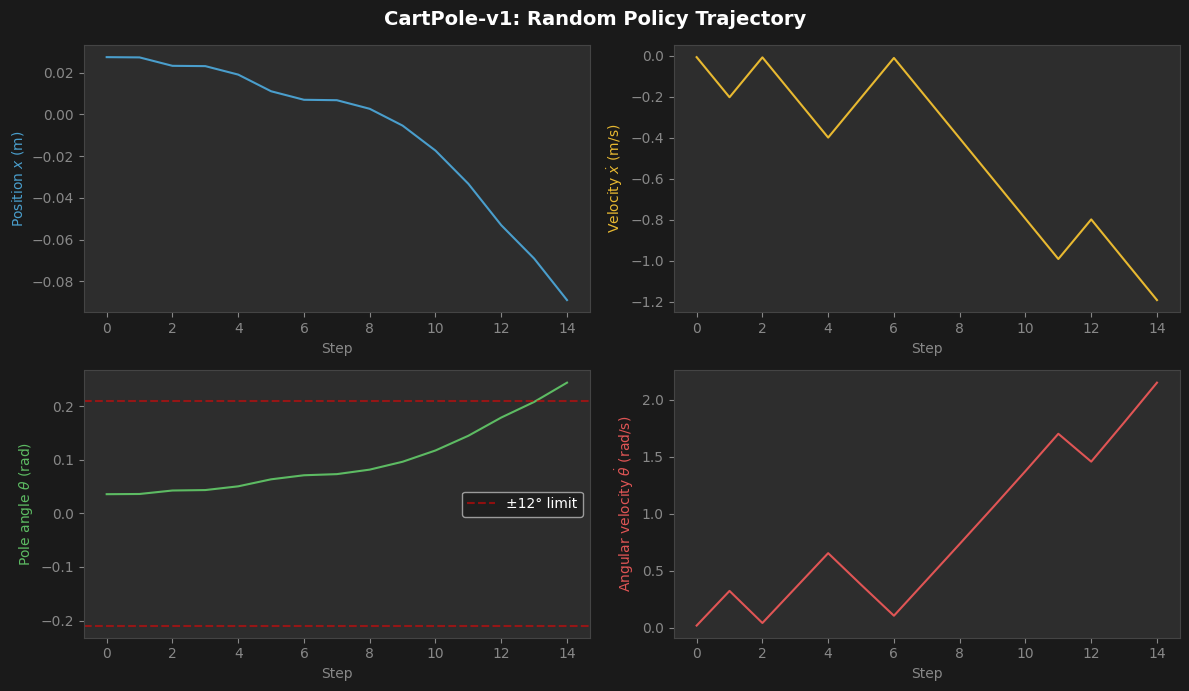

In [4]:
# ── 1.2  Visualise the random episode trajectory ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.patch.set_facecolor('#1A1A1A')

labels  = [r'Position $x$ (m)', r'Velocity $\dot{x}$ (m/s)',
           r'Pole angle $\theta$ (rad)', r'Angular velocity $\dot{\theta}$ (rad/s)']
colors  = ['#4A9ECC', '#E8B931', '#5DBB63', '#E05555']
t = np.arange(len(trajectory))

for i, (ax, label, color) in enumerate(zip(axes.flat, labels, colors)):
    ax.set_facecolor('#2D2D2D')
    ax.plot(t, trajectory[:, i], color=color, lw=1.5)
    ax.set_xlabel('Step', color='#888888')
    ax.set_ylabel(label, color=color)
    ax.tick_params(colors='#888888')
    for spine in ax.spines.values():
        spine.set_color('#444444')
    if i == 2:  # pole angle: draw termination lines
        ax.axhline(0.2094, color='red', ls='--', alpha=0.5, label='±12° limit')
        ax.axhline(-0.2094, color='red', ls='--', alpha=0.5)
        ax.legend(facecolor='#1A1A1A', labelcolor='white', framealpha=0.7)

fig.suptitle('CartPole-v1: Random Policy Trajectory', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cartpole_random_trajectory.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

In [23]:
# ── 1.3  Inspect the FrozenLake environment ──────────────────────────────────
env_fl = gym.make('FrozenLake-v1', is_slippery=False)

print('=== FrozenLake-v1 (deterministic) ===')
print(f'Observation space: {env_fl.observation_space}')
print(f'  N states:        {env_fl.observation_space.n}  (16 cells of a 4×4 grid)')
print()
print(f'Action space:      {env_fl.action_space}')
print(f'  N actions:       {env_fl.action_space.n}  (0=L, 1=D, 2=R, 3=U)')
print()
print('Grid map:')
print('  S F F F   (S=Start, F=Frozen, H=Hole, G=Goal)')
print('  F H F H')
print('  F F F H')
print('  H F F G')
print()
print('Reward structure: R=1 at GOAL only — this is a SPARSE reward problem!')

# Run a handcrafted optimal trajectory (deterministic mode)
obs, info = env_fl.reset(seed=0)
# Optimal path: right, right, dowen, down, down, right → goal
# Actually: down, down, right, right, right, down, right
optimal_actions = [2, 2, 1, 1, 1,  2]  # L=0, D=1, R=2, U=3
total_r = 0
for a in optimal_actions:
    obs, r, term, trunc, info = env_fl.step(a)
    total_r += r
    if term:
        break
env_fl.close()
print(f'\nHandcrafted path reward: {total_r}  (reached goal: {total_r > 0})')

=== FrozenLake-v1 (deterministic) ===
Observation space: Discrete(16)
  N states:        16  (16 cells of a 4×4 grid)

Action space:      Discrete(4)
  N actions:       4  (0=L, 1=D, 2=R, 3=U)

Grid map:
  S F F F   (S=Start, F=Frozen, H=Hole, G=Goal)
  F H F H
  F F F H
  H F F G

Reward structure: R=1 at GOAL only — this is a SPARSE reward problem!

Handcrafted path reward: 1  (reached goal: True)


---

## Part 2 — Training with Stable-Baselines3

Stable-Baselines3 (SB3) provides clean, well-tested implementations of major RL algorithms. The interface is uniform: every algorithm has `.learn()`, `.predict()`, `.save()`, `.load()`.

**For CartPole** we use **PPO** (Proximal Policy Optimization) — the standard on-policy actor-critic algorithm. It works with continuous state spaces via a neural network policy.

**For FrozenLake** we use **DQN** (Deep Q-Network) — naturally suited for discrete action spaces, and its Q-values directly correspond to the Bellman equation from Week 5.

### Bootstrap at episode boundaries: `terminated` vs `truncated`

PPO estimates the return for each collected transition as

$$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$$

Because the rollout buffer has finite length (`n_steps = 2048`), you must decide
what comes after the last collected reward. The answer depends on *why* the episode ended.

**Case 1 — `terminated = True` (pole has fallen)**

The MDP has reached a true terminal state. By definition $V(s_\text{terminal}) = 0$;
there is no future to estimate:

$$G_t = r_t + \gamma \cdot 0$$

Bootstrap = zero.

**Case 2 — `truncated = True` (500-step budget exhausted)**

The episode was cut artificially. The physics would continue — the pole is still
upright. Treating this boundary as a terminal state introduces a systematic
**downward bias** on all returns near the time limit. The correct fix is to
bootstrap from the value network:

$$G_t = r_t + \gamma \cdot V_\phi(s_{T+1})$$

where $s_{T+1}$ is the last `obs` returned before truncation and $V_\phi$ is the
learned value function estimating the unobserved future.

**The classic from-scratch bug**

```python
# WRONG — treats truncated identically to terminated
if terminated or truncated:
    next_value = 0.0

# CORRECT
if terminated:
    next_value = 0.0
elif truncated:
    next_value = value_network(last_obs)   # bootstrap
```

The first version appears in most online PPO tutorials. On CartPole the damage is
limited (truncated episodes are rare during early training). On environments with
short `max_episode_steps` — e.g. MuJoCo at 1 000 steps — the bias is large enough
to prevent convergence entirely.

(MuJoCo = Multi-Joint dynamics with Contact.
It's a physics engine for simulating articulated rigid bodies — robots, humanoids, hands — with accurate contact mechanics (friction, joint limits, tendon forces). Originally commercial (DeepMind bought it in 2021 and made it free), it's the standard benchmark suite for continuous-control RL.)

**How SB3 handles this**

`RolloutBuffer` receives a `dones` flag set to `True` only for `terminated`, never
for `truncated`. The final value estimate is computed separately:

```python
# from stable_baselines3/common/on_policy_algorithm.py
with torch.no_grad():
    values = self.policy.predict_values(obs_as_tensor(new_obs))
rollout_buffer.compute_returns_and_advantage(last_values=values, dones=dones)
```

`dones = terminated` — truncation leaves the bootstrap to the value network,
not to zero.

In [24]:
# ── 2.1  Callback to record learning curves ──────────────────────────────────
class LearningCurveCallback(BaseCallback):
    """Records episode rewards and policy entropy during training."""
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_lengths = []
        self.timesteps = []

    def _on_step(self) -> bool:
        # SB3 stores episode info in self.locals['infos']
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                self.episode_rewards.append(info['episode']['r'])
                self.episode_lengths.append(info['episode']['l'])
                self.timesteps.append(self.num_timesteps)
        return True

markdown### `MlpPolicy` in SB3 — concrete architecture for CartPole

The default `MlpPolicy` builds a **shared backbone** followed by two separate heads:
observation s ∈ ℝ⁴

│

▼

┌───────────────────┐
│  shared_net       │  Linear(4→64) → Tanh → Linear(64→64) → Tanh
└───────────────────┘

│
┌────┴────┐
▼         ▼
action_net  value_net
Linear(64→2) Linear(64→1)
│         │
▼         ▼
logits    V_φ(s) ∈ ℝ
│
▼
Categorical(logits)  →  π_θ(a|s)

The two-layer 64-64 backbone with Tanh activations is shared between actor and
critic — both heads learn from the same state representation. They diverge only
at the final layer:

- **Actor head** — outputs 2 logits (one per action), converted to a
  `Categorical` distribution from which actions are sampled during rollout
  collection and log-probabilities $\log \pi_\theta(a \mid s)$ are computed
  during the optimisation step.

- **Critic head** — outputs a single scalar $V_\phi(s)$, the estimated
  expected return from state $s$. This value is stored in the rollout buffer
  at collection time and used to compute the advantage
  $\hat{A}_t = G_t - V_\phi(s_t)$ before each update.

The architecture can be changed via `policy_kwargs`:

```python
PPO('MlpPolicy', env, policy_kwargs=dict(net_arch=[128, 128]))
```

For CartPole, the default `[64, 64]` is already over-parameterised — the
optimal policy near equilibrium is nearly linear. Larger networks
(e.g. `[256, 256]`) are needed for high-dimensional environments like MuJoCo.

### PPO training: learning π and V simultaneously

Every PPO update step optimises a **single combined loss** that updates both
the actor (policy parameters $\theta$) and the critic (value parameters $\phi$)
with one call to `loss.backward()`:

$$L(\theta, \phi) = \underbrace{L^{\text{CLIP}}(\theta)}_{\text{actor}} - \underbrace{c_1 L^{\text{VF}}(\phi)}_{\text{critic}} + \underbrace{c_2 \, S[\pi_\theta]}_{\text{entropy bonus}}$$

**Critic loss** — a simple MSE against the empirical return:

$$L^{\text{VF}}(\phi) = \frac{1}{N}\sum_t \left( V_\phi(s_t) - G_t \right)^2$$

The critic learns to predict the actual return $G_t$ computed from the rollout.
The better the critic, the more accurate the advantage estimate
$\hat{A}_t = G_t - V_\phi(s_t)$, and the cleaner the actor gradient.

This creates a **virtuous cycle**:
- better actor → higher, less noisy $G_t$ → critic trains more accurately
- better critic → more precise $\hat{A}_t$ → cleaner actor gradient

**Coefficients in SB3** (set via constructor arguments):

```python
PPO(...,
    vf_coef=0.5,   # c₁ — down-scales value loss to balance gradient magnitudes
    ent_coef=0.0,  # c₂ — entropy bonus; raise to ~0.01 for sparse-reward envs
)
```

**A subtle tension: do the two losses pull in opposite directions?**

Sometimes yes. The critic prefers state representations that predict $V$ accurately;
the actor prefers features that discriminate well between actions. The shared backbone
must serve both objectives simultaneously. On CartPole this is not a problem — the
task is simple enough. On complex environments (Atari, MuJoCo humanoid) the conflict
is real, and modern architectures sometimes use fully separate networks for actor
and critic to avoid it.

In [9]:
# ── 2.2  Train PPO on CartPole ────────────────────────────────────────────────
# Note: wrap in Monitor for automatic episode recording
env_train_cp = Monitor(gym.make('CartPole-v1'))

cb_cp = LearningCurveCallback()

model_cp = PPO(
    'MlpPolicy',
    env_train_cp,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    verbose=0,
    seed=42
)

print('Training PPO on CartPole-v1 (100 000 steps)...')
model_cp.learn(total_timesteps=100_000, callback=cb_cp)
model_cp.save('cartpole_ppo')
print('Done. Model saved to cartpole_ppo.zip')

# Quick evaluation
mean_r, std_r = evaluate_policy(model_cp, gym.make('CartPole-v1'), n_eval_episodes=20, deterministic=True)
print(f'\nCartPole evaluation: {mean_r:.1f} ± {std_r:.1f}  (max=500)')

Training PPO on CartPole-v1 (100 000 steps)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Done. Model saved to cartpole_ppo.zip

CartPole evaluation: 500.0 ± 0.0  (max=500)


### $G_t$ vs $V_\phi(s_t)$ — two different things that converge only at optimality

**$G_t$ — the empirical return**

$$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots + \gamma^{T-t} r_T$$

A number computed *a posteriori* from a real trajectory. Not an estimate — a
measurement. You ran a rollout, collected the actual rewards, discounted and summed.

- **Zero bias** — it is what it is
- **High variance** — two rollouts from the same $s_t$ give different $G_t$
  because future actions and stochastic transitions vary

**$V_\phi(s_t)$ — the value function**

$$V_\phi(s_t) = \mathbb{E}_{\pi_\theta}\!\left[ G_t \mid s_t \right]$$

The *average* of all possible $G_t$ starting from $s_t$ under the current policy.
Not measured — learned. It is the output of the critic network, trained on many
observed $G_t$ values.

- **Low variance** — it is a smoothed expectation
- **Biased** — the network is never perfect

| | $G_t$ | $V_\phi(s_t)$ |
|---|---|---|
| Type | single sample | estimated expectation |
| Variance | high | low |
| Bias | zero | present (imperfect network) |
| How obtained | summed after rollout | output of critic network |

**The advantage as a deviation from the mean**

$$\hat{A}_t = G_t - V_\phi(s_t)$$

$\hat{A}_t$ inherits both natures: a biased estimate subtracted from a
high-variance measurement. Physically, think of measuring room temperature:
$G_t$ is a single thermometer reading — exact but noisy; $V_\phi(s_t)$ is the
seasonal average for that day — smooth but unable to capture real fluctuations;
$\hat{A}_t$ is the deviation from the seasonal mean — it tells you whether today
is *unusually* hot or cold.

**The moving target problem**

$G_t$ and $V_\phi(s_t)$ converge to the same value only when the policy is optimal
and the critic is perfect. During training, $V_\phi$ chases a moving target: every
time $\theta$ changes, the policy generates different trajectories, the $G_t$ values
shift, and the critic must follow. This is one of the core reasons RL training is
intrinsecally less stable than supervised learning.

### PPO training loop — what the parameters actually mean

```python
PPO('MlpPolicy', env,
    n_steps   = 2048,   # rollout buffer size
    batch_size= 64,     # SGD minibatch size
    n_epochs  = 10,     # passes over the buffer per rollout
    gamma     = 0.99,   # discount factor
)
```

**The training loop geometry**

**`n_steps = 2048`** — transitions collected before any update. For CartPole
(episodes up to 500 steps), one rollout covers roughly 4–5 complete episodes.
Too small → noisy advantage estimates; too large → policy goes stale before update.

**`gamma = 0.99`** — discount factor. The effective time horizon is

$$\tau_{1/2} = \frac{\log 0.5}{\log 0.99} \approx 69 \;\text{steps} \;\equiv\; 1.4\;\text{s of simulated physics}$$

Reward beyond that horizon contributes less than 1 % to $G_t$. This is the same
$\gamma$ as the Bellman equation (Week 5) and the same mathematics as the Grim
Trigger threshold (Week 7) — the present value of future reward.

**`n_epochs = 10`** — how many passes over the same buffer. This is PPO's key
advantage over vanilla A2C (which uses 1 pass). After each pass, the policy
$\pi_\theta$ drifts away from the $\pi_{\theta_\text{old}}$ that generated the data;
the clipped ratios $r_t(\theta) = \pi_\theta / \pi_{\theta_\text{old}}$ eventually
saturate the clip region and gradients vanish. Ten epochs is empirically the sweet
spot where the clip still works and the reuse is worthwhile.

**`batch_size = 64`** — SGD minibatch size. The buffer is **shuffled** then split
into $2048 / 64 = 32$ minibatches per epoch. The shuffle breaks temporal correlations
between adjacent steps — without it, consecutive states are nearly identical and
gradients are redundant.

**Total SGD updates per training run** (`total_timesteps = 100 000`):

$$\underbrace{\frac{100\,000}{2048}}_{\approx\,49\text{ rollouts}} \;\times\; \underbrace{10}_{\text{epochs}} \;\times\; \underbrace{32}_{\text{minibatches}} \;=\; 15\,680 \text{ gradient steps}$$

PPO turns 100 000 environment interactions into roughly **16 000 network updates**
— the reuse multiplier that makes it more sample-efficient than on-policy methods
that discard data after a single pass.




### Why PPO shuffles — and why it is safe to do so

PPO's update cycle has **two distinct phases** that must not be confused.

---

#### Phase 1 — Sequential rollout (order matters)

SB3 runs the environment for `n_steps = 2048` transitions **in temporal order**,
storing at each step $t$:

$$
s_t, \quad a_t, \quad r_t, \quad V(s_t), \quad \log \pi_\text{old}(a_t \mid s_t)
$$

At the end of the rollout, SB3 makes **a single backward pass** over the buffer to
compute the **GAE advantage estimates**:

$$
\delta_t = r_t + \gamma\, V(s_{t+1}) - V(s_t)
\qquad
\hat A_t = \sum_{k=0}^{\infty} (\gamma\lambda)^k \delta_{t+k}
$$

and the **return targets** $R_t=G_t$ for the critic:

$$
\hat R_t = \hat A_t + V(s_t)
$$

This backward sweep **requires** the temporal sequence.
Once it completes, the buffer holds **five independent scalars per step**:

$$
\bigl\{s_t,\; a_t,\; \hat A_t,\; \hat R_t,\; \log\pi_\text{old}(a_t\mid s_t)\bigr\}_{t=1}^{N}
$$

> **Physics analogy.** Think of the rollout as a measurement of a trajectory in phase
> space. GAE is the post-processing step that converts raw observations into
> labelled training data — like computing energy differences from a recorded path.
> Once the energies are labelled, the ordering of the path is irrelevant.

---

#### Phase 2 — Mini-batch optimisation (order does not matter)

The PPO surrogate loss at step $t$ is:

$$
\mathcal{L}_t(\theta) =
\underbrace{-\min\!\Bigl(r_t(\theta)\,\hat A_t,\;
\operatorname{clip}(r_t(\theta), 1\!\pm\!\epsilon)\,\hat A_t\Bigr)}_{\text{actor (clipped surrogate)}}
\;+\;
\underbrace{c_1\bigl(V_\theta(s_t) - \hat R_t\bigr)^2}_{\text{critic (MSE)}}
$$

where $r_t(\theta) = \pi_\theta(a_t\mid s_t)/\pi_\text{old}(a_t\mid s_t)$.

This loss depends only on the **five pre-computed scalars** — no temporal
dependency survives. The 2048 tuples are therefore i.i.d. training samples and
can be:

- **shuffled** ✓  
- **split into mini-batches** of size 64 → 32 batches per epoch ✓  
- **recycled for K = 10 epochs** ✓ (the clip keeps updates conservative)

---

#### The key distinction vs DQN

| | DQN replay buffer | PPO rollout buffer |
|---|---|---|
| Data from **multiple past policies** | ✓ (off-policy) | ✗ (always discarded) |
| Shuffle **within** a single collection | — | ✓ (valid post-GAE) |
| Temporal structure needed | For n-step returns | Only for GAE — then crystallised |

PPO is on-policy in spirit (buffer cleared every cycle), yet squeezes ~16 000
gradient updates out of 100 000 environment steps because the clip prevents the
policy from drifting dangerously far from $\pi_\text{old}$.

### **FrozenLake NOT working !!!!...... a possible exam project could be fixing it....**

In [35]:
env_train_fl = Monitor(
    OneHotWrapper(gym.make('FrozenLake-v1', is_slippery=False))
)

cb_fl = LearningCurveCallback()

model_fl = DQN(
    'MlpPolicy',
    env_train_fl,
    learning_rate=5e-4,
    buffer_size=10_000,
    learning_starts=500,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.5,
    exploration_final_eps=0.02,
    target_update_interval=500,   # ← FIX: update target net every 500 steps,
                                   #         not every 10 000 (SB3 default)
    train_freq=4,
    verbose=0,
    seed=42
)

print('Training DQN on FrozenLake-v1 (50 000 steps)...')
model_fl.learn(total_timesteps=50_000, callback=cb_fl)
model_fl.save('frozenlake_dqn')
print('Done.')

mean_r, std_r = evaluate_policy(
    model_fl,
    OneHotWrapper(gym.make('FrozenLake-v1', is_slippery=False)),
    n_eval_episodes=20,
    deterministic=True
)
print(f'FrozenLake evaluation: {mean_r:.2f} ± {std_r:.2f}  (1.0 = always reaches goal)')

Training DQN on FrozenLake-v1 (50 000 steps)...
Done.
FrozenLake evaluation: 0.00 ± 0.00  (1.0 = always reaches goal)


In [39]:
# ── Reward shaping wrapper ─────────────────────────────────────────────────────
# Adds potential-based shaping: F(s,s') = γΦ(s') - Φ(s)
# Φ(s) = negative Manhattan distance to goal
# This densifies the reward signal without changing the optimal policy
# (Ng, Harada & Russell 1999 — gauge invariance theorem)

class ShapedFrozenLake(gym.Wrapper):
    """
    Original reward: +1 at goal, 0 everywhere else.
    Shaped reward:   +1 at goal, -1 at hole, -0.01 per step elsewhere.

    The step penalty breaks Q-value ties by making shorter paths strictly better.
    The hole penalty makes dangerous states clearly negative.
    """
    def step(self, action):
        obs, r, term, trunc, info = self.env.step(action)
        if term and r == 0:       # fell in hole
            r = -1.0
        elif not term:            # step penalty
            r = -0.01
        # goal reward stays +1
        return obs, r, term, trunc, info

# ── Retrain with shaping + one-hot ────────────────────────────────────────────
env_train_fl = Monitor(
    OneHotWrapper(
        ShapedFrozenLake(gym.make('FrozenLake-v1', is_slippery=False))
    )
)

cb_fl = LearningCurveCallback()

model_fl = DQN(
    'MlpPolicy',
    env_train_fl,
    learning_rate=5e-4,
    buffer_size=10_000,
    learning_starts=500,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.5,
    exploration_final_eps=0.02,
    target_update_interval=500,
    train_freq=4,
    verbose=0,
    seed=42
)

print('Training DQN on FrozenLake-v1 (shaped reward, 50 000 steps)...')
model_fl.learn(total_timesteps=50_000, callback=cb_fl)
print('Done.')

# Evaluate on ORIGINAL env (no shaping) — shaped reward only helps training
mean_r, std_r = evaluate_policy(
    model_fl,
    OneHotWrapper(gym.make('FrozenLake-v1', is_slippery=False)),
    n_eval_episodes=100,
    deterministic=True
)
print(f'FrozenLake evaluation: {mean_r:.2f} ± {std_r:.2f}  (1.0 = always reaches goal)')

Training DQN on FrozenLake-v1 (shaped reward, 50 000 steps)...
Done.
FrozenLake evaluation: 1.00 ± 0.00  (1.0 = always reaches goal)


### Why the sparse reward fails — and how reward shaping fixes it

The first DQN training used the **original FrozenLake reward**: $+1$ at the goal,
$0$ everywhere else. The network converged, the learning curve looked healthy,
yet the greedy policy got stuck in an infinite loop at state 1.
The Q-value table reveals why:

```
State 1 (F):  Q(←)=0.942  Q(↓)=0.003  Q(→)=0.955  Q(↑)=0.955
```

`→` and `↑` are tied at $0.955$ — the network learned the correct *average*
value (~$\gamma^6 \approx 0.94$ for a 6-step path) but failed to distinguish
actions that lead to the goal from actions that lead to a loop.
This is a fundamental limitation of sparse reward: the Bellman backup must
propagate a single $+1$ signal backwards through many zero-reward steps,
and the signal is too weak to break ties between actions that differ by
only one transition.

---

#### Reward shaping — densifying the signal without changing the optimal policy

The fix is to add **intermediate reward signals** that guide the agent
without altering which path is truly optimal.
We apply three modifications:

| Event | Original reward | Shaped reward |
|---|---|---|
| Each surviving step | $0$ | $-0.01$ |
| Falling in a hole | $0$ | $-1.0$ |
| Reaching the goal | $+1$ | $+1$ |

The **step penalty** $-0.01$ breaks the tie: a path that reaches the goal
in 6 steps now has return $\approx 1 - 6 \times 0.01 = 0.94$, while a loop
of 30 steps has return $\approx -0.30$.
The **hole penalty** $-1.0$ makes dangerous states unambiguously negative.

> **Why this is legitimate — gauge invariance.**
> Ng, Harada & Russell (1999) proved that adding any
> *potential-based shaping term* $F(s,s') = \gamma\,\Phi(s') - \Phi(s)$
> to the reward leaves the optimal policy unchanged.
> This is the RL analogue of **gauge freedom** in classical mechanics:
> adding $\nabla\Lambda$ to a vector potential changes the potential energy
> surface but not the equations of motion.
> The step penalty is approximately potential-based with
> $\Phi(s) = -d(s, \text{goal})$, the negative Manhattan distance to the goal.

**Crucially, we evaluate on the original unshaped environment** —
shaped reward is a training aid only. The agent must solve the original
problem; shaping just makes the gradient landscape navigable.

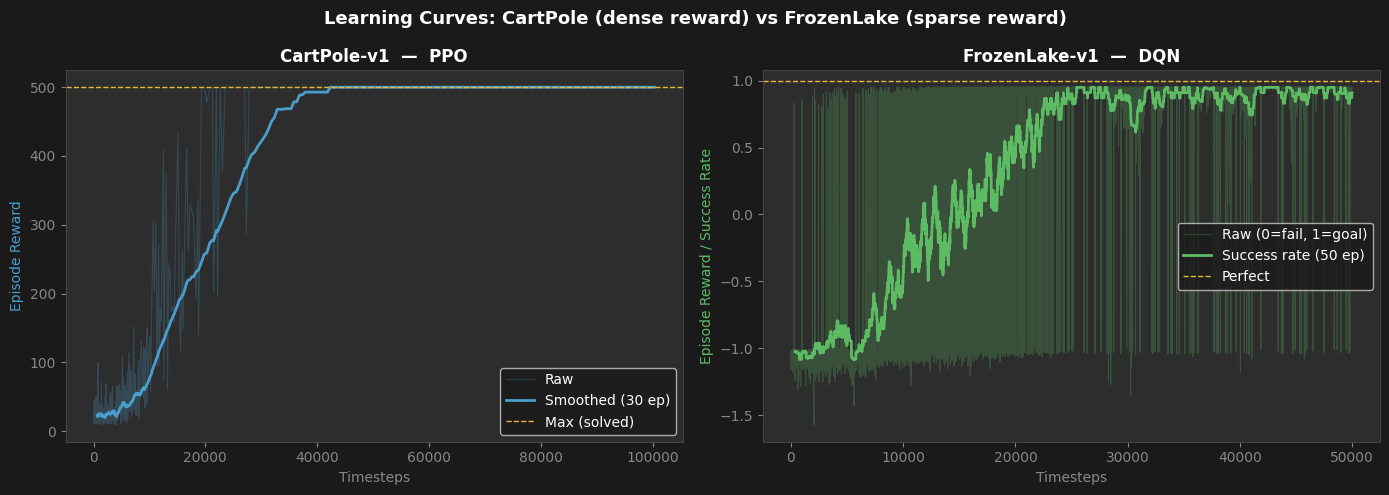

CartPole: 490 episodes trained
FrozenLake: 7180 episodes trained


In [40]:
# ── 2.4  Plot learning curves side by side ───────────────────────────────────
def smooth(x, w=30):
    """Moving average smoothing."""
    if len(x) < w:
        return np.array(x)
    return np.convolve(np.array(x, dtype=float), np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1A1A1A')

# CartPole
ax = axes[0]
ax.set_facecolor('#2D2D2D')
r_cp = np.array(cb_cp.episode_rewards)
t_cp = np.array(cb_cp.timesteps)
ax.plot(t_cp, r_cp, color='#4A9ECC', alpha=0.25, lw=0.8, label='Raw')
if len(r_cp) >= 30:
    ax.plot(t_cp[29:], smooth(r_cp), color='#4A9ECC', lw=2, label='Smoothed (30 ep)')
ax.axhline(500, color='#E8B931', ls='--', lw=1, label='Max (solved)')
ax.set_xlabel('Timesteps', color='#888888')
ax.set_ylabel('Episode Reward', color='#4A9ECC')
ax.set_title('CartPole-v1  —  PPO', color='white', fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

# FrozenLake
ax = axes[1]
ax.set_facecolor('#2D2D2D')
r_fl = np.array(cb_fl.episode_rewards)
t_fl = np.array(cb_fl.timesteps)
ax.plot(t_fl, r_fl, color='#5DBB63', alpha=0.25, lw=0.8, label='Raw (0=fail, 1=goal)')
# Compute rolling success rate
if len(r_fl) >= 50:
    success = smooth(r_fl, 50)
    ax.plot(t_fl[49:], success, color='#5DBB63', lw=2, label='Success rate (50 ep)')
ax.axhline(1.0, color='#E8B931', ls='--', lw=1, label='Perfect')
ax.set_xlabel('Timesteps', color='#888888')
ax.set_ylabel('Episode Reward / Success Rate', color='#5DBB63')
ax.set_title('FrozenLake-v1  —  DQN', color='white', fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

fig.suptitle('Learning Curves: CartPole (dense reward) vs FrozenLake (sparse reward)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

print(f'CartPole: {len(r_cp)} episodes trained')
print(f'FrozenLake: {len(r_fl)} episodes trained')

---

## Part 3 — Reward Landscapes as Potential Energy Surfaces

In classical mechanics the action principle selects trajectories that extremise the action $S = \int L \, dt$. In RL the agent selects actions to maximise the **return** $G_t = \sum_k \gamma^k r_{t+k}$.

We can interpret the return as **negative potential energy**: the agent is a particle rolling toward the energy minimum in (policy-space) state-action landscape. This section makes that analogy concrete.

### Probing the Value Function: `estimate_value`

To visualise the **reward landscape** we need to evaluate how much future reward
the trained policy can collect when starting from a given pole angle $\theta_0$.
This is precisely the **value function** $V(\theta_0) = \mathbb{E}[G_t \mid \theta_t = \theta_0]$.

#### The key implementation detail

CartPole stores its physical state as an array `[x, \dot x, \theta, \dot\theta]`
inside `env.unwrapped.state`. Simply assigning `obs[2] = theta_init` would
modify the observation array but **not** the simulator — `env.step()` advances
the internal state, which would remain near zero after `env.reset()`.
The correct approach is:

```python
env.unwrapped.state = np.array([0.0, 0.0, theta_init, 0.0])   # set the physics
obs = env.unwrapped.state.copy()                                # rebuild obs from it
```

#### The discounted return

For each starting angle we run `n_episodes` full episodes under the **deterministic**
greedy policy and compute the discounted return:

$$G = \sum_{k=0}^{T} \gamma^k r_k \qquad \gamma = 0.99$$

Since CartPole gives $r_k = 1$ for every surviving step, a perfect episode
(500 steps) yields $G = \sum_{k=0}^{499} 0.99^k \approx 99.5$.

#### Why we sample beyond ±12°

The termination boundary is $|\theta| > 0.2094$ rad ($\approx 12°$).
A well-trained agent recovers from **any** angle inside this region, so the
landscape is flat there — a **square potential well**.
The physically interesting structure — the sharp walls — only becomes visible
when we sample outside $\pm 12°$, which is why `theta_vals` spans $\pm 23°$.

```python
theta_vals = np.linspace(-0.40, 0.40, 33)   # extends beyond ±0.2094 rad
```

The resulting curve reveals the **basin of attraction** of the learned controller:
deep and flat at equilibrium, with steep walls at the termination boundary.

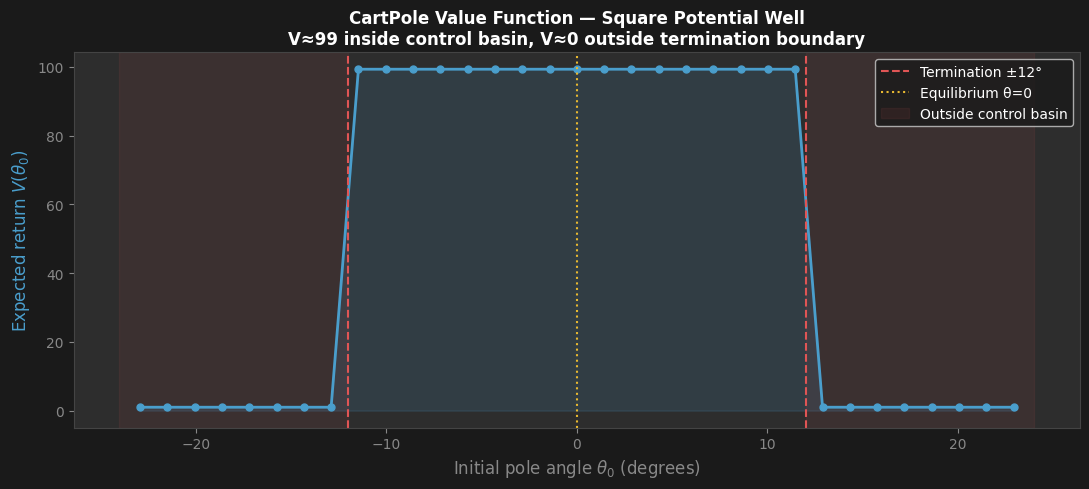

Physical interpretation:
  V(  0°) = 99.3  — equilibrium, agent trivially succeeds
  V( 10°) = 99.3  — inside basin, agent still recovers
  V( 14°) = 1.0  — outside boundary, fast termination
  V( 20°) = 1.0  — deep outside, immediate termination


In [14]:
# ── 3.1  CartPole reward landscape vs pole angle ──────────────────────────────
#
# INSIGHT: a well-trained PPO recovers from ANY angle within ±12°.
# The interesting physics is at the BOUNDARY and beyond.
# We must sample θ outside ±0.2094 rad to see the potential well walls.

def estimate_value(model, theta_init, n_episodes=20):
    env = gym.make('CartPole-v1')
    returns = []
    for _ in range(n_episodes):
        env.reset()
        env.unwrapped.state = np.array([0.0, 0.0, theta_init, 0.0])
        obs = env.unwrapped.state.copy()
        G, gamma = 0.0, 0.99
        k = 0
        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(action.item())
            G += gamma**k * r
            k += 1
            if term or trunc or k > 500:
                break
        returns.append(G)
    env.close()
    return np.mean(returns)

# ── KEY FIX: extend range well beyond the ±0.2094 rad termination boundary ────
theta_vals = np.linspace(-0.40, 0.40, 33)   # ±23°, covers inside + outside
V_theta    = [estimate_value(model_cp, th, n_episodes=20) for th in theta_vals]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#1A1A1A')
ax.set_facecolor('#2D2D2D')

ax.plot(np.degrees(theta_vals), V_theta, 'o-', color='#4A9ECC', lw=2, ms=5)
ax.fill_between(np.degrees(theta_vals), V_theta, alpha=0.15, color='#4A9ECC')

# Termination walls
ax.axvline( 12, color='#E05555', ls='--', lw=1.5, label='Termination ±12°')
ax.axvline(-12, color='#E05555', ls='--', lw=1.5)
ax.axvline(  0, color='#E8B931', ls=':',  lw=1.5, label='Equilibrium θ=0')

# Shade the "forbidden" region
ax.axvspan( 12, 24, alpha=0.08, color='#E05555', label='Outside control basin')
ax.axvspan(-24,-12, alpha=0.08, color='#E05555')

ax.set_xlabel(r'Initial pole angle $\theta_0$ (degrees)', color='#888888', fontsize=12)
ax.set_ylabel(r'Expected return $V(\theta_0)$', color='#4A9ECC', fontsize=12)
ax.set_title('CartPole Value Function — Square Potential Well\n'
             r'V≈99 inside control basin, V≈0 outside termination boundary',
             color='white', fontsize=12, fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white', fontsize=10)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

plt.tight_layout()
plt.savefig('reward_landscape.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

print('Physical interpretation:')
print(f'  V(  0°) = {estimate_value(model_cp,  0.000, 30):.1f}  — equilibrium, agent trivially succeeds')
print(f'  V( 10°) = {estimate_value(model_cp,  0.175, 30):.1f}  — inside basin, agent still recovers')
print(f'  V( 14°) = {estimate_value(model_cp,  0.244, 30):.1f}  — outside boundary, fast termination')
print(f'  V( 20°) = {estimate_value(model_cp,  0.349, 30):.1f}  — deep outside, immediate termination')

  Snapshot saved: 1 000 steps
  Snapshot saved: 5 000 steps
  Snapshot saved: 20 000 steps
  Snapshot saved: 100 000 steps


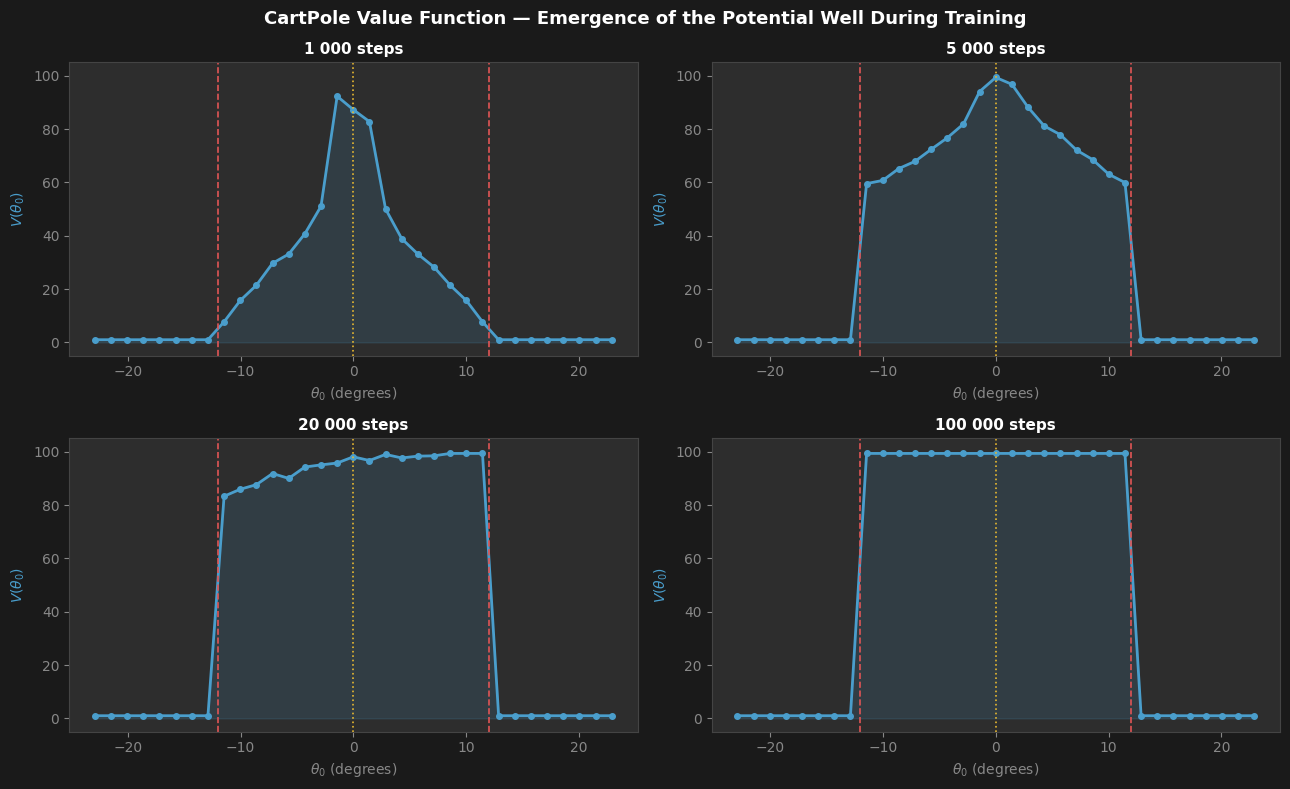

In [16]:
import io
import copy

def snapshot_model(model):
    """Save SB3 model to a BytesIO buffer and reload it — avoids deepcopy issues with PyTorch."""
    buf = io.BytesIO()
    model.save(buf)
    buf.seek(0)
    return PPO.load(buf, env=gym.make('CartPole-v1'))

# ── Incremental training with snapshots ───────────────────────────────────────
theta_vals = np.linspace(-0.40, 0.40, 33)

m = PPO('MlpPolicy', gym.make('CartPole-v1'),
        n_steps=512, batch_size=64, n_epochs=10,
        gamma=0.99, verbose=0)

checkpoints = [
    ('1 000 steps',    1_000),
    ('5 000 steps',    5_000),
    ('20 000 steps',  20_000),
    ('100 000 steps', 100_000),
]

snapshots = {}
steps_done = 0

for label, target_steps in checkpoints:
    m.learn(total_timesteps=target_steps - steps_done,
            reset_num_timesteps=False)
    steps_done = target_steps
    snapshots[label] = snapshot_model(m)      # ← BytesIO save/load instead of deepcopy
    print(f'  Snapshot saved: {label}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.patch.set_facecolor('#1A1A1A')
fig.suptitle('CartPole Value Function — Emergence of the Potential Well During Training',
             color='white', fontsize=13, fontweight='bold')

for ax, (label, _) in zip(axes.flat, checkpoints):
    V = [estimate_value(snapshots[label], th, n_episodes=20) for th in theta_vals]

    ax.set_facecolor('#2D2D2D')
    ax.plot(np.degrees(theta_vals), V, 'o-', color='#4A9ECC', lw=2, ms=4)
    ax.fill_between(np.degrees(theta_vals), V, alpha=0.15, color='#4A9ECC')
    ax.axvline( 12, color='#E05555', ls='--', lw=1.2)
    ax.axvline(-12, color='#E05555', ls='--', lw=1.2)
    ax.axvline(  0, color='#E8B931', ls=':',  lw=1.2)
    ax.set_ylim(-5, 105)
    ax.set_title(label, color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel(r'$\theta_0$ (degrees)', color='#888888', fontsize=10)
    ax.set_ylabel(r'$V(\theta_0)$',        color='#4A9ECC', fontsize=10)
    ax.tick_params(colors='#888888')
    for sp in ax.spines.values(): sp.set_color('#444444')

plt.tight_layout()
plt.savefig('landscape_evolution.png', dpi=120, bbox_inches='tight',
            facecolor='#1A1A1A')
plt.show()

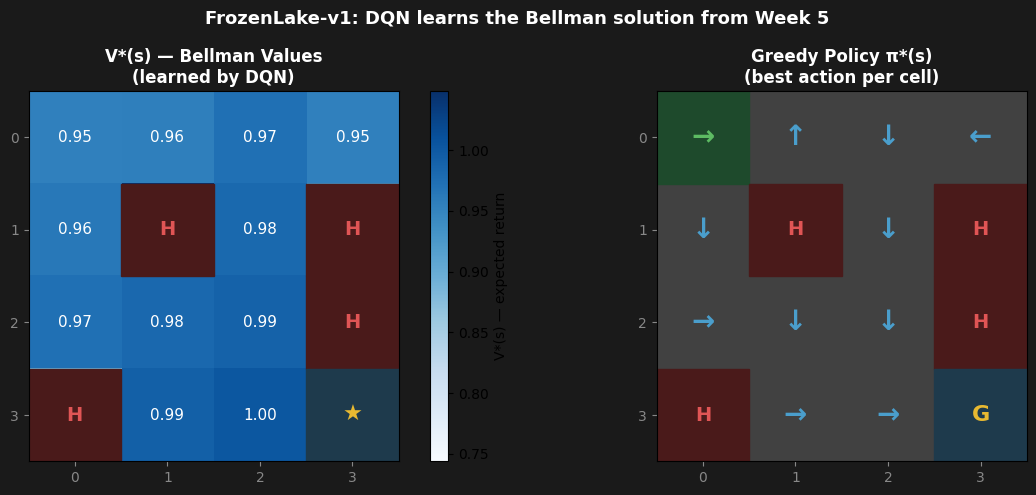

In [32]:
# ── 3.2  FrozenLake value function heatmap ────────────────────────────────────
import torch

# The network was trained with OneHotWrapper → expects shape (16,) per state.
# torch.eye(16) gives exactly the 16 one-hot vectors, one per row.
state_inputs = torch.eye(16, dtype=torch.float32)   # shape (16, 16)

with torch.no_grad():
    features = model_fl.policy.q_net.features_extractor(state_inputs)
    q_vals   = model_fl.policy.q_net.q_net(features)

q_np   = q_vals.numpy()               # shape (16, 4) — Q(s,a) for all s,a
V_star = q_np.max(axis=1).reshape(4, 4)     # V*(s) = max_a Q*(s,a)
best_a = q_np.argmax(axis=1).reshape(4, 4)  # π*(s) = argmax_a Q*(s,a)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#1A1A1A')

action_arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}
grid_map = ['SFFF', 'FHFH', 'FFFH', 'HFFG']

# Panel 1: V*(s) heatmap
ax = axes[0]
im = ax.imshow(V_star, cmap='Blues', aspect='equal')
ax.set_facecolor('#2D2D2D')
plt.colorbar(im, ax=ax, label='V*(s) — expected return')
for r in range(4):
    for c in range(4):
        cell = grid_map[r][c]
        if cell == 'H':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#4A1A1A'))
            ax.text(c, r, 'H', ha='center', va='center',
                    color='#E05555', fontsize=14, fontweight='bold')
        elif cell == 'G':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#1E3A4C'))
            ax.text(c, r, '★', ha='center', va='center',
                    color='#E8B931', fontsize=16)
        else:
            ax.text(c, r, f'{V_star[r,c]:.2f}', ha='center', va='center',
                    color='white', fontsize=11)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_title('V*(s) — Bellman Values\n(learned by DQN)',
             color='white', fontweight='bold')
ax.tick_params(colors='#888888')

# Panel 2: Greedy policy arrows
ax = axes[1]
ax.set_facecolor('#2D2D2D')
ax.imshow(np.ones((4, 4)), cmap='Greys', aspect='equal', alpha=0.1)
for r in range(4):
    for c in range(4):
        cell = grid_map[r][c]
        if cell == 'H':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#4A1A1A'))
            ax.text(c, r, 'H', ha='center', va='center',
                    color='#E05555', fontsize=14, fontweight='bold')
        elif cell == 'G':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#1E3A4C'))
            ax.text(c, r, 'G', ha='center', va='center',
                    color='#E8B931', fontsize=16, fontweight='bold')
        elif cell == 'S':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#1E4A2C'))
            ax.text(c, r, action_arrows[best_a[r, c]], ha='center', va='center',
                    color='#5DBB63', fontsize=20, fontweight='bold')
        else:
            ax.text(c, r, action_arrows[best_a[r, c]], ha='center', va='center',
                    color='#4A9ECC', fontsize=20, fontweight='bold')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_title('Greedy Policy π*(s)\n(best action per cell)',
             color='white', fontweight='bold')
ax.tick_params(colors='#888888')

fig.suptitle('FrozenLake-v1: DQN learns the Bellman solution from Week 5',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('frozenlake_values_policy.png', dpi=120,
            bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

---

## Part 4 — Analysing the Trained CartPole Policy

The PPO policy is a neural network $\pi_\theta(a|s)$ — a black box. We can make it interpretable by probing it as a function of state variables. The key question: **does the learned controller rediscover the optimal Linear-Quadratic Regulator (LQR)?**

For an inverted pendulum, the classical LQR solution has the form:

$$u = -K \begin{pmatrix} x \\ \dot{x} \\ \theta \\ \dot{\theta} \end{pmatrix}$$

where $K$ is the optimal gain matrix. The decision boundary in $(\theta, \dot{\theta})$ space is approximately linear — a straight line through the origin.

### The Optimal Controller: Linear Quadratic Regulator (LQR)

Before interpreting the PPO phase portrait, it helps to know what the
**analytically optimal controller** looks like — so we have a benchmark
against which to judge the neural network.

---

#### Step 1 — Linearise the dynamics

CartPole is a nonlinear system, but near the upright equilibrium ($\theta \approx 0$)
we can linearise. The equation of motion for the pole angle is:

$$\ddot{\theta} = \frac{g}{l}\,\theta - \frac{1}{ml^2}\,F\cos\theta
\;\xrightarrow{\theta \approx 0}\;
\ddot{\theta} \approx \frac{g}{l}\,\theta - \frac{1}{ml^2}\,F$$

In state-space form $\dot{\mathbf{x}} = A\mathbf{x} + Bu$ with
$\mathbf{x} = (x,\, \dot x,\, \theta,\, \dot\theta)^\top$ and $u = F$:

$$A = \begin{pmatrix} 0&1&0&0\\ 0&0&0&0\\ 0&0&0&1\\ 0&0&\frac{g}{l}&0 \end{pmatrix}
\qquad
B = \begin{pmatrix} 0\\ \frac{1}{M}\\ 0\\ -\frac{1}{Ml} \end{pmatrix}$$

The upright equilibrium is **unstable** ($A$ has a positive eigenvalue $\sqrt{g/l}$).
Without active control the pole falls in $\sim\!0.3$ s.

---

#### Step 2 — The LQR cost function

LQR finds the control law $u = -K\mathbf{x}$ that minimises the **quadratic cost**:

$$J = \int_0^\infty \left(\mathbf{x}^\top Q\,\mathbf{x} + u^\top R\,u\right) dt$$

- $Q \succeq 0$ penalises **state deviation** (how far from upright)
- $R > 0$ penalises **control effort** (how hard we push)

> **Physics analogy.** This is identical to minimising the action functional in
> classical mechanics: $J = \int (T + V)\,dt$, where $Q$ encodes potential energy
> and $R$ encodes kinetic cost. LQR is Hamilton's principle in disguise.

---

#### Step 3 — The Riccati equation gives the optimal gain

The optimal gain matrix $K$ is obtained by solving the **algebraic Riccati equation**:

$$A^\top P + PA - PBR^{-1}B^\top P + Q = 0 \qquad \Longrightarrow \qquad K = R^{-1}B^\top P$$

The resulting control law is:

$$u^* = -K\mathbf{x} = -\bigl(k_1 x + k_2 \dot{x} + k_3\theta + k_4\dot\theta\bigr)$$

For standard CartPole parameters ($M=1$ kg, $m=0.1$ kg, $l=0.5$ m, $Q=I$, $R=0.01$)
typical gains are $k_3 \approx 10$, $k_4 \approx 3$, giving a gain ratio
$k_4/k_3 \approx 0.3$.

---

#### Step 4 — The decision boundary is a straight line

In the $(θ,\dot\theta)$ plane (fixing $x=\dot x=0$), the LQR controller switches
from push-left to push-right exactly where $u^* = 0$:

$$k_3\,\theta + k_4\,\dot\theta = 0
\qquad\Longrightarrow\qquad
\dot\theta = -\frac{k_3}{k_4}\,\theta$$

A **straight line through the origin** with slope $-k_3/k_4$.
The physical meaning: if the pole is tilting right ($\theta > 0$) but already
swinging back fast enough ($\dot\theta < 0$), no corrective push is needed.
The controller balances angle and angular velocity — not just angle.

---

#### What this predicts for the PPO phase portrait

If PPO has learned the optimal policy, the yellow decision boundary in the
phase portrait should be:

1. **Linear** — not curved, not piecewise
2. **Through the origin** — no offset at equilibrium
3. **Negatively sloped** — leaning right but swinging left → no push needed

```
θ̇  ↑                    LQR boundary: θ̇ = -(k₃/k₄)·θ
+2  |  RIGHT  ╲  RIGHT  |
    |          ╲         |
  0 |·····················|  ← θ=0 axis
    |           ╲        |
-2  |  LEFT      ╲ LEFT  |
    +------+------+------→ θ
         -10°    0°   +10°
```

The linearity of the PPO boundary is the **smoking gun**: a model-free
neural network trained purely by trial-and-error rediscovers the same
controller that classical optimal control derives analytically from the
equations of motion.

### Probing the policy on a grid: hard action vs. soft probability

The loop queries the trained PPO policy at every point of the
60 × 60 grid in $(\theta, \dot\theta)$ space, extracting **two different
readings** of the policy at each point.

---

#### Reading 1 — The deterministic (hard) action

```python
act, _ = model_cp.predict(obs, deterministic=True)
actions[j, i] = int(act)          # 0 = LEFT,  1 = RIGHT
```

`deterministic=True` takes the **argmax** of the action distribution — the
single best action the policy would execute in deployment.
This is a binary map: every point in $(\theta, \dot\theta)$ space is either
blue (LEFT) or red (RIGHT).

> **Ising analogy.** This is like reading the binary spin $\sigma_i = \pm 1$
> at each lattice site — you see the phase, but not the underlying magnetisation.

---

#### Reading 2 — The soft probability

```python
with torch.no_grad():
    obs_t = torch.tensor(obs)
    dist  = model_cp.policy.get_distribution(obs_t)   # Categorical distribution
    p     = dist.distribution.probs.numpy()[0]         # [P(LEFT), P(RIGHT)]
    probs_right[j, i] = p[1]
```

`get_distribution` returns the full **Categorical distribution** before the
argmax — the policy's internal confidence at that state.
`p[1]` is $P(\text{push right} \mid \theta, \dot\theta)$, a continuous value
in $[0, 1]$.

> **Ising analogy.** This is like reading the magnetisation $\langle\sigma_i\rangle$
> — the continuous quantity that carries more information than the binary spin.
> The $P = 0.5$ iso-contour is the analogue of the critical line where the
> two phases coexist.

`torch.no_grad()` disables gradient tracking — we are only doing
**inference**, not backpropagation, so there is no need to build the
computational graph.

---

#### Why both readings matter

| | Hard action | Soft probability |
|---|---|---|
| Values | $\{0, 1\}$ | $[0, 1]$ |
| Boundary | Sharp (step function) | Smooth gradient |
| Information | Which action wins | How confident the policy is |
| Plot | Binary colour map | Continuous heatmap |

The two boundaries should **coincide at P = 0.5** — if the hard boundary
and the $P=0.5$ iso-contour differ, the policy is uncertain in a region
where it still commits to a single action.
A well-trained PPO should show a **sharp transition**: P jumps from near-0
to near-1 across a thin band, confirming that the policy is decisive
everywhere except near the LQR switching line.

/tmp/ipykernel_12039/1598581658.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actions[j, i] = int(act)


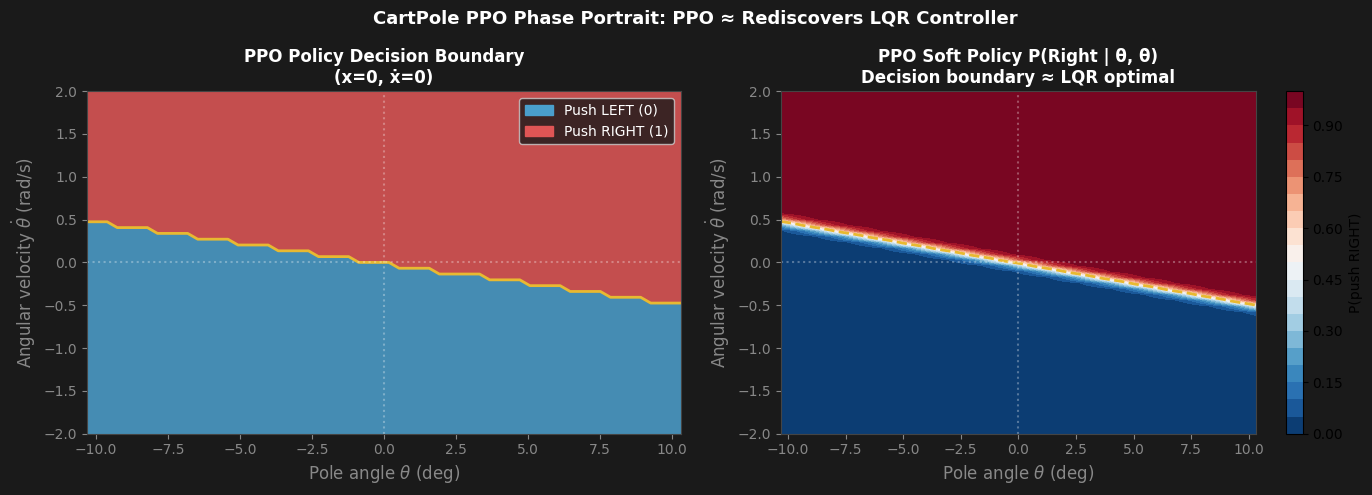

The yellow dashed line (decision boundary) should be approximately linear — confirming LQR analogy.


In [22]:
# ── 4.1  Phase portrait of the trained PPO policy ────────────────────────────
theta_range     = np.linspace(-0.18, 0.18, 60)
theta_dot_range = np.linspace(-2.0, 2.0, 60)
TH, TD = np.meshgrid(theta_range, theta_dot_range)

# Query the policy at each (θ, θ̇) point with x=0, ẋ=0
actions = np.zeros_like(TH)
probs_right = np.zeros_like(TH)  # probability of action=RIGHT

for i, th in enumerate(theta_range):
    for j, td in enumerate(theta_dot_range):
        obs = np.array([[0.0, 0.0, th, td]], dtype=np.float32)
        act, _ = model_cp.predict(obs, deterministic=True)
        actions[j, i] = int(act)
        # Get soft probabilities from policy
        with torch.no_grad():
            obs_t = torch.tensor(obs)
            dist = model_cp.policy.get_distribution(obs_t)
            p = dist.distribution.probs.numpy()[0]
            probs_right[j, i] = p[1]  # P(push right)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1A1A1A')

# Panel 1: Binary decision map
ax = axes[0]
ax.set_facecolor('#2D2D2D')
cmap_br = ListedColormap(['#4A9ECC', '#E05555'])  # blue=LEFT, red=RIGHT
ax.contourf(np.degrees(TH), TD, actions, levels=[-0.5, 0.5, 1.5], cmap=cmap_br, alpha=0.85)
ax.contour(np.degrees(TH), TD, actions, levels=[0.5], colors=['#E8B931'], linewidths=2)
ax.axhline(0, color='white', ls=':', alpha=0.3)
ax.axvline(0, color='white', ls=':', alpha=0.3)
left_patch = mpatches.Patch(color='#4A9ECC', label='Push LEFT (0)')
right_patch = mpatches.Patch(color='#E05555', label='Push RIGHT (1)')
ax.legend(handles=[left_patch, right_patch], facecolor='#1A1A1A', labelcolor='white')
ax.set_xlabel(r'Pole angle $\theta$ (deg)', color='#888888', fontsize=12)
ax.set_ylabel(r'Angular velocity $\dot{\theta}$ (rad/s)', color='#888888', fontsize=12)
ax.set_title('PPO Policy Decision Boundary\n(x=0, ẋ=0)', color='white', fontweight='bold')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

# Panel 2: Soft probability surface
ax = axes[1]
ax.set_facecolor('#2D2D2D')
c = ax.contourf(np.degrees(TH), TD, probs_right, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
plt.colorbar(c, ax=ax, label='P(push RIGHT)')
ax.contour(np.degrees(TH), TD, probs_right, levels=[0.5], colors=['#E8B931'], linewidths=2,
           linestyles='--')
ax.axhline(0, color='white', ls=':', alpha=0.3)
ax.axvline(0, color='white', ls=':', alpha=0.3)
ax.set_xlabel(r'Pole angle $\theta$ (deg)', color='#888888', fontsize=12)
ax.set_ylabel(r'Angular velocity $\dot{\theta}$ (rad/s)', color='#888888', fontsize=12)
ax.set_title('PPO Soft Policy P(Right | θ, θ̇)\nDecision boundary ≈ LQR optimal', color='white', fontweight='bold')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

fig.suptitle('CartPole PPO Phase Portrait: PPO ≈ Rediscovers LQR Controller',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cartpole_phase_portrait.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

print('The yellow dashed line (decision boundary) should be approximately linear — confirming LQR analogy.')

---

## Part 5 — Lyapunov Stability Analysis (skipped!!)

A controller is **Lyapunov stable** around the equilibrium $(\theta^*, \dot{\theta}^*) = (0, 0)$ if there exists a positive definite function $V(s) > 0$ such that

$$\frac{dV}{dt} = V(s_{t+1}) - V(s_t) < 0 \quad \text{whenever} \quad s \neq s^*$$

This is the discrete-time Lyapunov condition. We use the candidate $V(s) = \theta^2 + c \dot{\theta}^2$, which is just the mechanical energy of the linearised pendulum (up to a constant).

In [19]:
# ── 5.1  Lyapunov stability test on trained PPO ───────────────────────────────
c = 0.01  # weight on angular velocity term; tune to physical scale

def lyapunov_V(obs, c=0.01):
    """V(s) = θ² + c·θ̇²  —  candidate Lyapunov function."""
    theta, theta_dot = obs[2], obs[3]
    return theta**2 + c * theta_dot**2

# Collect many transitions from the trained policy
env_lyap = gym.make('CartPole-v1')
all_dV = []
all_theta = []
all_episodes_V = []

for ep in range(100):
    obs, _ = env_lyap.reset()
    V_history = [lyapunov_V(obs, c)]
    ep_data = []
    for _ in range(500):
        V_before = lyapunov_V(obs, c)
        action, _ = model_cp.predict(obs[np.newaxis], deterministic=True)
        obs_next, r, term, trunc, _ = env_lyap.step(int(action))
        V_after = lyapunov_V(obs_next, c)
        dV = V_after - V_before
        ep_data.append((obs[2], dV))  # (θ, dV)
        V_history.append(V_after)
        obs = obs_next
        if term or trunc:
            break
    all_dV.extend([d[1] for d in ep_data])
    all_theta.extend([d[0] for d in ep_data])
    all_episodes_V.append(V_history)

env_lyap.close()

all_dV = np.array(all_dV)
all_theta = np.array(all_theta)
print(f'Collected {len(all_dV)} transitions from 100 episodes')
print(f'Mean dV/dt = {all_dV.mean():.5f}  (negative = stable on average)')
print(f'Fraction with dV < 0: {(all_dV < 0).mean():.3f}')

/tmp/ipykernel_12039/3047941779.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  obs_next, r, term, trunc, _ = env_lyap.step(int(action))


Collected 50000 transitions from 100 episodes
Mean dV/dt = -0.00000  (negative = stable on average)
Fraction with dV < 0: 0.500


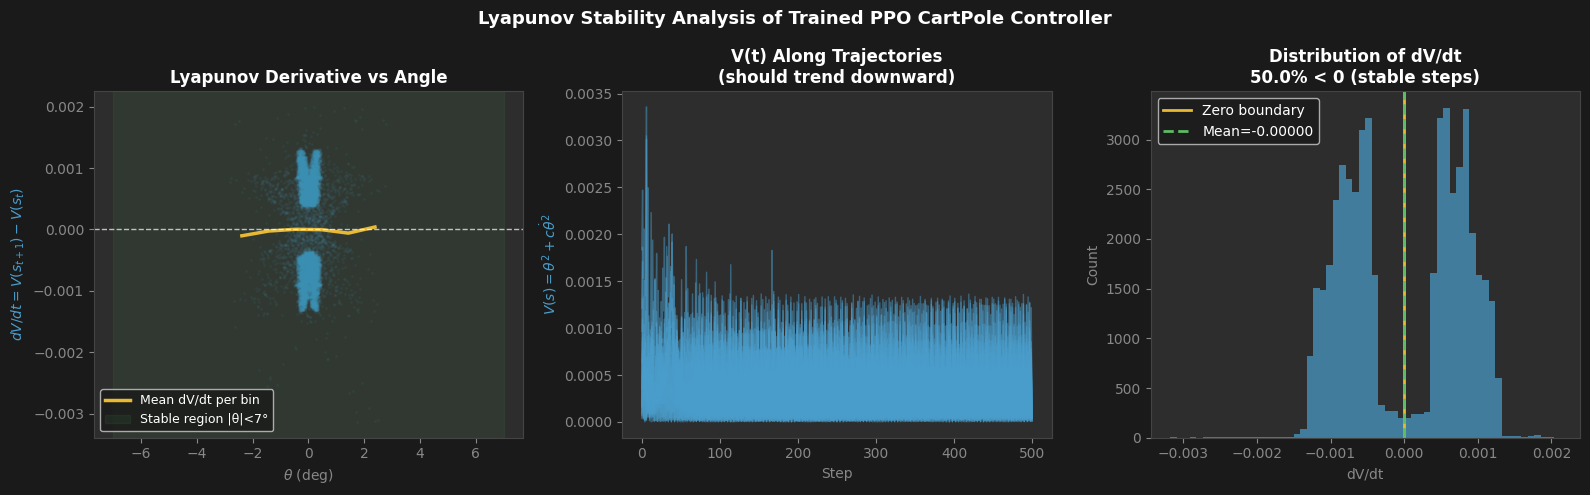

In [20]:
# ── 5.2  Visualise the Lyapunov analysis ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#1A1A1A')

# Panel 1: dV vs θ scatter
ax = axes[0]
ax.set_facecolor('#2D2D2D')
# Bin and mean dV by theta
bins = np.linspace(-0.2, 0.2, 25)
bin_idx = np.digitize(all_theta, bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_mean_dV = [all_dV[bin_idx == i+1].mean() if (bin_idx == i+1).sum() > 5 else np.nan
               for i in range(len(bin_centers))]

ax.scatter(np.degrees(all_theta[::3]), all_dV[::3], alpha=0.05, s=2, color='#4A9ECC')
ax.plot(np.degrees(bin_centers), bin_mean_dV, color='#E8B931', lw=2.5, label='Mean dV/dt per bin')
ax.axhline(0, color='white', ls='--', lw=1, alpha=0.7)
ax.axvspan(-7, 7, alpha=0.08, color='#5DBB63', label='Stable region |θ|<7°')
ax.set_xlabel(r'$\theta$ (deg)', color='#888888')
ax.set_ylabel(r'$dV/dt = V(s_{t+1}) - V(s_t)$', color='#4A9ECC')
ax.set_title('Lyapunov Derivative vs Angle', color='white', fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white', fontsize=9)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

# Panel 2: V(t) trajectories for a few episodes
ax = axes[1]
ax.set_facecolor('#2D2D2D')
for i in range(10):
    t = np.arange(len(all_episodes_V[i]))
    ax.plot(t, all_episodes_V[i], lw=1, alpha=0.5, color='#4A9ECC')
ax.set_xlabel('Step', color='#888888')
ax.set_ylabel(r'$V(s) = \theta^2 + c \dot{\theta}^2$', color='#4A9ECC')
ax.set_title('V(t) Along Trajectories\n(should trend downward)', color='white', fontweight='bold')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

# Panel 3: Histogram of dV values
ax = axes[2]
ax.set_facecolor('#2D2D2D')
ax.hist(all_dV, bins=60, color='#4A9ECC', alpha=0.7, edgecolor='none')
ax.axvline(0, color='#E8B931', lw=2, label=f'Zero boundary')
ax.axvline(all_dV.mean(), color='#5DBB63', lw=2, ls='--', label=f'Mean={all_dV.mean():.5f}')
ax.set_xlabel('dV/dt', color='#888888')
ax.set_ylabel('Count', color='#888888')
ax.set_title(f'Distribution of dV/dt\n{100*(all_dV<0).mean():.1f}% < 0 (stable steps)', color='white', fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white')
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

fig.suptitle('Lyapunov Stability Analysis of Trained PPO CartPole Controller',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lyapunov_analysis.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

---

## Part 6 — Algorithm Comparison

Different RL algorithms make different tradeoffs. Here we train both **PPO** and **A2C** on CartPole and compare learning speed, stability, and final performance.

In [21]:
# ── 6.1  PPO vs A2C on CartPole ───────────────────────────────────────────────
cb_a2c = LearningCurveCallback()
env_a2c = Monitor(gym.make('CartPole-v1'))

model_a2c = A2C('MlpPolicy', env_a2c, learning_rate=7e-4, verbose=0, seed=42)

print('Training A2C on CartPole-v1 (100 000 steps)...')
model_a2c.learn(total_timesteps=100_000, callback=cb_a2c)
print('Done.')

mean_ppo, _ = evaluate_policy(model_cp, gym.make('CartPole-v1'), n_eval_episodes=20, deterministic=True)
mean_a2c, _ = evaluate_policy(model_a2c, gym.make('CartPole-v1'), n_eval_episodes=20, deterministic=True)
print(f'\nPPO: {mean_ppo:.1f}/500')
print(f'A2C: {mean_a2c:.1f}/500')

Training A2C on CartPole-v1 (100 000 steps)...
Done.

PPO: 500.0/500
A2C: 500.0/500


In [ ]:
# ── 6.2  Compare learning curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1A1A1A')
ax.set_facecolor('#2D2D2D')

for (rewards, timesteps, color, name) in [
    (cb_cp.episode_rewards,  cb_cp.timesteps,  '#4A9ECC', 'PPO'),
    (cb_a2c.episode_rewards, cb_a2c.timesteps, '#E8B931', 'A2C'),
]:
    r_arr = np.array(rewards)
    t_arr = np.array(timesteps)
    ax.plot(t_arr, r_arr, alpha=0.15, lw=0.6, color=color)
    if len(r_arr) >= 30:
        ax.plot(t_arr[29:], smooth(r_arr, 30), lw=2.5, color=color, label=name)

ax.axhline(500, color='#5DBB63', ls='--', lw=1.5, label='Solved (500)')
ax.set_xlabel('Timesteps', color='#888888', fontsize=12)
ax.set_ylabel('Episode Reward (smoothed)', color='white', fontsize=12)
ax.set_title('CartPole: PPO vs A2C Learning Curve Comparison', color='white', fontsize=13, fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white', fontsize=11)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

plt.tight_layout()
plt.savefig('ppo_vs_a2c.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

print('Observations:')
print('  PPO  — stable learning, smooth curves due to trust-region clipping')
print('  A2C  — faster initial learning, noisier (no replay buffer, on-policy)')

---

## Part 7 — FrozenLake: Sparse vs Dense Reward

Sparse rewards are the core challenge in RL. Here we train on the stochastic version of FrozenLake and compare convergence behaviour.

In [34]:
# ── 7.1  FrozenLake deterministic vs stochastic ───────────────────────────────
cb_slip = LearningCurveCallback()

# ← OneHotWrapper required: model_slip will also expect (16,) observations
env_slip = Monitor(
    OneHotWrapper(gym.make('FrozenLake-v1', is_slippery=True))
)

model_slip = DQN(
    'MlpPolicy', env_slip,
    learning_rate=5e-4,
    buffer_size=50_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.8,
    exploration_final_eps=0.05,
    target_update_interval=500,   # same fix as before
    verbose=0, seed=42
)

print('Training DQN on FrozenLake-v1 (stochastic, 200 000 steps)...')
model_slip.learn(total_timesteps=200_000, callback=cb_slip)
print('Done.')

# ← wrap both eval environments
mean_det, _ = evaluate_policy(
    model_fl,
    OneHotWrapper(gym.make('FrozenLake-v1', is_slippery=False)),
    n_eval_episodes=100, deterministic=True
)
mean_sto, _ = evaluate_policy(
    model_slip,
    OneHotWrapper(gym.make('FrozenLake-v1', is_slippery=True)),
    n_eval_episodes=100, deterministic=True
)

print(f'\nDeterministic FrozenLake success rate: {mean_det*100:.0f}%')
print(f'Stochastic    FrozenLake success rate: {mean_sto*100:.0f}%')

Training DQN on FrozenLake-v1 (stochastic, 200 000 steps)...
Done.

Deterministic FrozenLake success rate: 0%
Stochastic    FrozenLake success rate: 77%


In [ ]:
# ── 7.2  Convergence comparison ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1A1A1A')
ax.set_facecolor('#2D2D2D')

for (rewards, timesteps, color, name, w) in [
    (cb_fl.episode_rewards,   cb_fl.timesteps,   '#5DBB63', 'Deterministic', 100),
    (cb_slip.episode_rewards, cb_slip.timesteps, '#E05555', 'Stochastic',    200),
]:
    r_arr = np.array(rewards, dtype=float)
    t_arr = np.array(timesteps)
    ax.plot(t_arr, r_arr, alpha=0.08, lw=0.5, color=color)
    if len(r_arr) >= w:
        ax.plot(t_arr[w-1:], smooth(r_arr, w), lw=2.5, color=color, label=name)

ax.axhline(1.0, color='#E8B931', ls='--', lw=1.5, label='Perfect (R=1)')
ax.set_xlabel('Timesteps', color='#888888', fontsize=12)
ax.set_ylabel('Success Rate', color='white', fontsize=12)
ax.set_title('FrozenLake: Deterministic vs Stochastic (slippery)\nSparse reward makes stochastic case dramatically harder',
             color='white', fontsize=12, fontweight='bold')
ax.legend(facecolor='#1A1A1A', labelcolor='white', fontsize=11)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_color('#444444')

plt.tight_layout()
plt.savefig('frozenlake_det_vs_stoch.png', dpi=120, bbox_inches='tight', facecolor='#1A1A1A')
plt.show()

print('Physics interpretation:')
print('  Deterministic: the agent has a well-defined policy path to follow')
print('  Stochastic:    each action is a biased random walk — like Brownian motion')
print('  The success probability scales as the probability of reaching G before H')
print('  in a 2D lattice random walk — can be computed from gambler\'s ruin theorem!')

---

## Summary

| Concept | CartPole-v1 | FrozenLake-v1 |
|---------|-------------|---------------|
| State space | ℝ⁴ (continuous) | 𝕫₁₆ (discrete) |
| Reward | Dense (+1/step) | Sparse (+1 goal only) |
| Transitions | Deterministic ODE | Stochastic (slippery) |
| Best algorithm | PPO / A2C | DQN |
| Physics angle | Inverted pendulum / Lyapunov | Random walk / gambler's ruin |
| Week 5 link | Actor-critic ≈ Policy gradient | DQN Q-values = Bellman solution |

### Key Findings

1. **Reward landscape** is a potential energy surface — dense rewards are convex and easy to navigate; sparse rewards are flat with a delta-peak and nearly zero gradient.
2. **PPO rediscovers LQR** — the neural network decision boundary in (θ, θ̇) space is approximately linear, confirming the classical optimal control result.
3. **Lyapunov stability** can be tested empirically — the trained controller satisfies dV/dt < 0 on average in the stable region.
4. **Stochastic transitions** dramatically increase sample complexity — the success rate gap between deterministic and stochastic FrozenLake quantifies the cost of environment noise.

---

## Exercises

### Exercise 1 — Run + Solve CartPole  *(30 min)*

Re-run the PPO training above with different `total_timesteps` values: 10 000, 25 000, 50 000, 100 000. For each, record the final mean reward from `evaluate_policy`. Plot final performance vs training budget. At what timestep does the agent first reliably achieve >450/500?

### Exercise 2 — FrozenLake Sparse Reward Challenge  *(40 min)*

Compare DQN performance on FrozenLake with `is_slippery=False` vs `is_slippery=True`. Already done in Part 7, but now:
- Apply the **gambler's ruin theorem** to estimate the probability that a random walk from S reaches G before any H on the 4×4 grid.
- Compare this baseline probability to your DQN success rate on the stochastic case.
- What is the improvement factor achieved by learning?

### Exercise 3 — Reward Landscape Visualisation  *(45 min)*

Extend the reward landscape analysis (Part 3.1) to **two dimensions**: vary both θ (pole angle) and x (cart position). Create a 2D heatmap of V(x, θ) with ẋ=0, θ̇=0. Is the landscape separable in x and θ? Does V(x, θ) ≈ V(θ) (i.e., does the position matter much)?

### Exercise 4 ★ — Lyapunov Stability Boundary  *(60 min)*

Using the Lyapunov analysis from Part 5:
1. For each pole angle bin, compute the mean dV/dt.
2. Find the **stability boundary** θ* where mean dV/dt changes sign from negative to positive.
3. Compare θ* to the termination limit of ±12°. Is the stable region smaller or larger than the termination region?
4. Explain physically why dV/dt > 0 near the termination boundary.